# Turbulence in Fluids — Hot-Wire Signal Analysis
**Round jet, $d = 14 mm \quad \nu = 1.48×10⁻⁵ m²/s  \quad \rho = 1.22 kg/m³ \quad T_{room} = 15 °C$**

---
# Setup

## 0 · Setup & Imports

In [243]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ── Physical constants ────────────────────────────────────────────────────────
NU   = 1.48e-5   # kinematic viscosity [m²/s]
RHO  = 1.22      # density [kg/m³]
D    = 14e-3     # jet diameter [m]
COLORS = ['#378ADD', '#1D9E75', '#D85A30', '#EF9F27', '#7F77DD', '#D4537E']
print('Setup complete.')

Setup complete.


## 1 · Load Data Files

In [244]:
FILE_PATHS = [
    'G06_XoD00.5625_R00_Freq34.5.txt',
    'G06_XoD05.0000_R00_Freq34.5.txt',
    'G06_XoD10.0000_R00_Freq34.5.txt',
    #'G06_XoD10.0000_R25_Freq34.5.txt',
    'G06_XoD15.0000_R00_Freq34.5.txt',
    'G06_XoD20.0000_R00_Freq34.5.txt',
]

def parse_header(filepath):
    """Extract metadata from comment line: XoD, fs, R, Freq."""
    with open(filepath, 'r') as f:
        header = f.readline().strip('# \n')
    meta = {}
    for token in header.split(','):
        key, val = token.strip().split('=')
        try:
            meta[key.strip()] = float(val.replace('kHz','').replace('Hz','').replace('mm','').strip())
        except:
            meta[key.strip()] = val.strip()
    meta['fs_Hz'] = meta.get('fs') * 1e3   # kHz → Hz
    meta['R_m']   = meta.get('R') * 1e-3      # mm  → m
    meta['header_str'] = header
    return meta

def load_signal(filepath):
    """Load velocity time series [m/s] from a txt file with a single header line."""
    data = np.loadtxt(filepath, comments='#')
    return data

signals = []
for fp in FILE_PATHS:
    path = Path(fp)
    if not path.exists():
        print(f'  [SKIP] {fp} — file not found')
        continue
    meta = parse_header(path)
    U    = load_signal(path)
    meta['U']  = U
    meta['dt'] = 1.0 / meta['fs_Hz']
    meta['t']  = np.arange(len(U)) * meta['dt']
    meta['label'] = f"x/d={meta.get('XoD','?'):.4g}, R={int(meta.get('R',0))}mm"
    signals.append(meta)
    print(f"  Loaded: {meta['label']} , N={len(U):,} , fs={meta['fs_Hz']/1e3:.1f} kHz")

print(f'\n{len(signals)} signals loaded.')

  Loaded: x/d=0.5625, R=0mm , N=1,000,000 , fs=100.0 kHz
  Loaded: x/d=5, R=0mm , N=1,000,000 , fs=100.0 kHz
  Loaded: x/d=10, R=0mm , N=1,000,000 , fs=100.0 kHz
  Loaded: x/d=15, R=0mm , N=1,000,000 , fs=100.0 kHz
  Loaded: x/d=20, R=0mm , N=1,000,000 , fs=100.0 kHz

5 signals loaded.


## 2 · Select Working Signal
Change `IDX` to analyse a different file.

In [245]:
IDX = 0   # ← change this (0 … len(signals)-1)

sig = signals[IDX]
U   = sig['U']
dt  = sig['dt']
fs  = sig['fs_Hz']
t   = sig['t']
label = sig['label']
print(f'Working signal: {label}')
print(f'  N = {len(U):,}  |  T_total = {t[-1]:.4f} s  |  dt = {dt*1e6:.2f} µs')

Working signal: x/d=0.5625, R=0mm
  N = 1,000,000  |  T_total = 10.0000 s  |  dt = 10.00 µs


---
# Roberto

---
## 3 · Introduction

---
## 4 · Description of Measurement Locations

---
## 5 · Zoom of Instantaneous Velocity and Velocity Derivative

---
## 6 · Mean Velocity, RMS Velocity & Turbulence Intensity

---
# André

---
## 7 · Mean Velocity Derivative, RMS & Turbulence Intensity of Derivative

### Functions

In [246]:
def compute_mean_derivative(U, dt):
    dU = np.gradient(U, dt)
    mean_dU = np.mean(dU)
    return dU, mean_dU

In [247]:
def compute_rms_derivative(dU):
    mean_dU = np.mean(dU)
    rms_dU = np.sqrt(np.mean(mean_dU**2))
    return rms_dU

In [248]:
def compute_TI_derivative(dU):
    mean_dU = np.mean(dU)
    dU_prime = dU - mean_dU
    TI_dU = np.sqrt(np.mean(dU_prime**2)) / np.abs(mean_dU)
    return TI_dU

### Plots

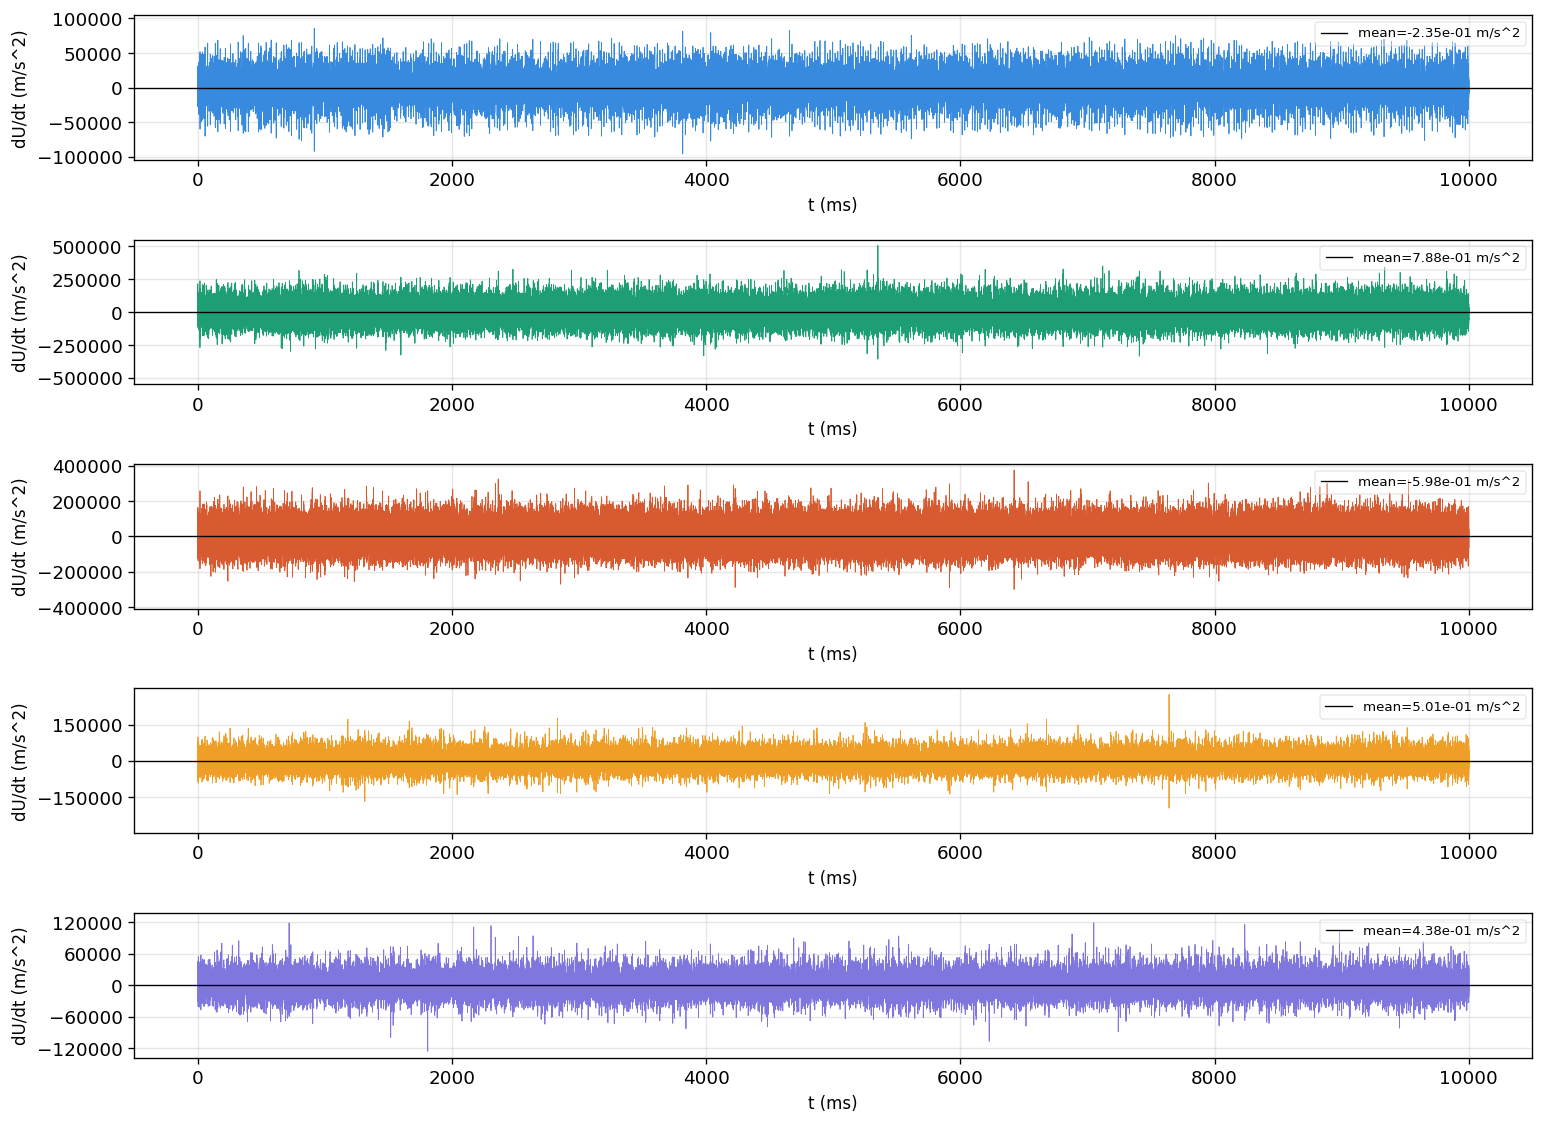

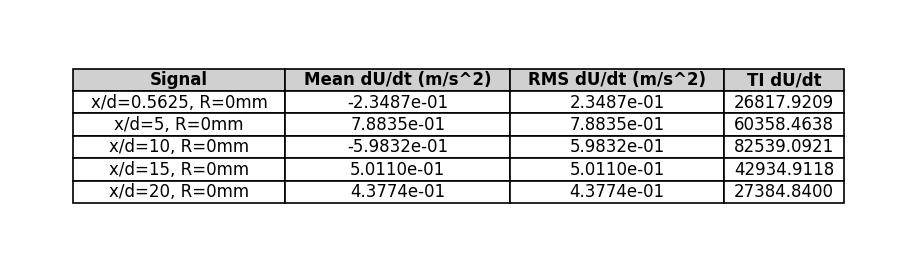

In [249]:
def plot_section7(signals, zoom_start_ms=0.0, size=-1):
    n_sigs = len(signals)
    fig, axes = plt.subplots(n_sigs, 1,
                             figsize=(13, 1.9 * n_sigs))
    if n_sigs == 1:
        axes = [axes]

    table_rows = []

    for ax, sig, c in zip(axes, signals, COLORS):
        dU, mean_dU = compute_mean_derivative(sig['U'], sig['dt'])
        rms_dU     = compute_rms_derivative(dU)
        TI_dU      = compute_TI_derivative(dU)

        n_zoom_start = int(zoom_start_ms * 1e-3 / dt) if zoom_start_ms > 0 else None
        n_zoom_end = n_zoom_start + int(size * 1e-3 / dt) if size > 0 else None
        tz = t[n_zoom_start:n_zoom_end] * 1e3

        ax.plot(tz, dU[n_zoom_start:n_zoom_end], lw=0.5, color=c)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, symmetric=True))
        ax.set_xlabel('t (ms)', fontsize=10)
        ax.set_ylabel('dU/dt (m/s^2)', fontsize=10)
        ax.axhline(mean_dU, color='k', lw=0.8, ls='-',
                   label=f'mean={mean_dU:.2e} m/s^2')
        ax.legend(fontsize=8, loc='upper right', framealpha=0.4)

        table_rows.append([
            sig['label'],
            f"{mean_dU:.4e}",
            f"{rms_dU:.4e}",
            f"{TI_dU:.4f}",
        ])

    fig.tight_layout()

    col_labels = ['Signal', 'Mean dU/dt (m/s^2)', 'RMS dU/dt (m/s^2)', 'TI dU/dt']
    fig_table, ax_table = plt.subplots(figsize=(8, 0.4 * (n_sigs + 1)))
    ax_table.axis('off')

    tbl = ax_table.table(
        cellText=table_rows,
        colLabels=col_labels,
        loc='center',
        cellLoc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.auto_set_column_width(col=list(range(len(col_labels))))

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#d0d0d0')
        tbl[0, j].set_text_props(fontweight='bold')

    fig_table.tight_layout()
    plt.show()

plot_section7(signals)

---
## 8 · Skewness — Velocity and Velocity Derivative

### Functions

In [250]:
def compute_skewness(signal):
    signal_prime = signal - np.mean(signal)
    S_signal = np.mean(signal_prime**3) / ((np.mean(signal_prime**2))**1.5)
    return S_signal

### Plots

In [251]:
def plot_section8(signals):
    print(f"\n{'Signal':<25} {'S(U)':>10} {'S(∂U/∂t)':>12}")
    print('-' * 50)

    for sig, c in zip(signals, COLORS):
        dU = np.gradient(sig['U'], sig['dt'])
        S_u = compute_skewness(sig['U'])
        S_dU = compute_skewness(dU)

        print(f"{sig['label']:<25} {S_u:>10.4f} {S_dU:>12.4f}")
        

plot_section8(signals)


Signal                          S(U)     S(∂U/∂t)
--------------------------------------------------
x/d=0.5625, R=0mm            -0.0599       0.0933
x/d=5, R=0mm                 -1.0647       0.0621
x/d=10, R=0mm                -0.2107       0.2154
x/d=15, R=0mm                 0.1057       0.2125
x/d=20, R=0mm                 0.0918       0.3091


---
## 9 · Flatness — Velocity and Velocity Derivative

### Functions

In [252]:
def compute_flatness(signal):
    signal_prime = signal - np.mean(signal)
    F_signal = np.mean(signal_prime**4) / (np.mean(signal_prime**2)**2)
    return F_signal

### Plots

In [253]:
def plot_section9(signals):
    print(f"\n{'Signal':<25} {'F(U)':>10} {'F(∂U/∂t)':>12}")
    print('-' * 50)

    for sig, c in zip(signals, COLORS):
        dU = np.gradient(sig['U'], sig['dt'])
        F_u = compute_flatness(sig['U'])
        F_dU = compute_flatness(dU)

        print(f"{sig['label']:<25} {F_u:>10.4f} {F_dU:>12.4f}")
        

plot_section9(signals)


Signal                          F(U)     F(∂U/∂t)
--------------------------------------------------
x/d=0.5625, R=0mm             3.3387      13.7363
x/d=5, R=0mm                  5.2166       4.8362
x/d=10, R=0mm                 2.7768       3.7321
x/d=15, R=0mm                 2.8042       4.7131
x/d=20, R=0mm                 2.8146       5.3151


---
## 10 · PDF of Velocity & Velocity Derivative

### Functions

In [254]:
def compute_pdf(signal, n_bins=500):
    signal_prime = signal - np.mean(signal)
    sigma        = np.std(signal_prime)
    signal_norm  = signal_prime / sigma          

    counts, bin_edges = np.histogram(signal_norm, bins=n_bins,
                                     range=(-15, 15), density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    mask        = counts > 0

    gauss_pdf = np.exp(-bin_centers**2 / 2) / np.sqrt(2 * np.pi)  

    return signal_norm, bin_centers[mask], counts[mask], gauss_pdf[mask]

### Plots

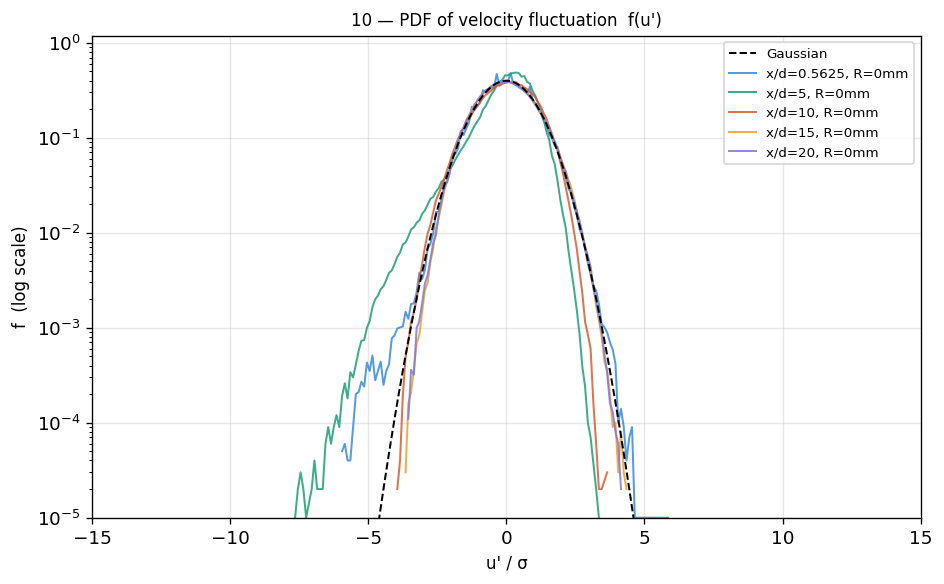

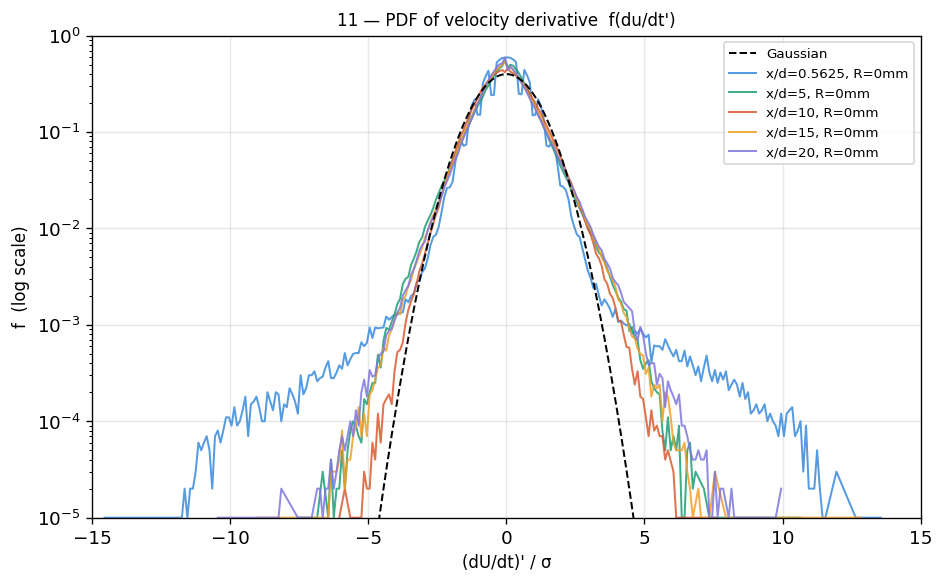

In [255]:
def plot_section10(signals, n_bins=300):
    fig, ax = plt.subplots(figsize=(8, 5))

    _, centers0, _, gauss0 = compute_pdf(signals[0]['U'], n_bins)
    ax.semilogy(centers0, gauss0, 'k--', lw=1.2, label='Gaussian', zorder=5)

    for sig, c in zip(signals, COLORS):
        _, centers, pdf, _ = compute_pdf(sig['U'], n_bins)
        ax.semilogy(centers, pdf, lw=1.2, color=c,
                    alpha=0.85, label=sig['label'])

    ax.set_xlabel("u' / \u03c3", fontsize=10)
    ax.set_ylabel('f  (log scale)', fontsize=10)
    ax.set_xlim(-15, 15)
    ax.set_ylim(bottom=1e-5)
    ax.set_title("10 — PDF of velocity fluctuation  f(u')", fontsize=10)
    ax.legend(fontsize=8, loc='upper right', ncol=1)
    fig.tight_layout()
    plt.show()

def plot_section11(signals, n_bins=300):
    fig, ax = plt.subplots(figsize=(8, 5))

    _, centers0, _, gauss0 = compute_pdf(np.gradient(signals[0]['U'], signals[0]['dt'])[1:-1], n_bins)
    ax.semilogy(centers0, gauss0, 'k--', lw=1.2, label='Gaussian', zorder=5)

    for sig, c in zip(signals, COLORS):
        _, centers, pdf, _ = compute_pdf(np.gradient(sig['U'], sig['dt'])[1:-1], n_bins)
        ax.semilogy(centers, pdf, lw=1.2, color=c,
                    alpha=0.85, label=sig['label'])

    ax.set_xlabel("(dU/dt)' / \u03c3", fontsize=10)   
    ax.set_ylabel('f  (log scale)', fontsize=10)
    ax.set_xlim(-15, 15)
    ax.set_ylim(top=1, bottom=1e-5)
    ax.set_title("11 — PDF of velocity derivative  f(du/dt')", fontsize=10)
    ax.legend(fontsize=8, loc='upper right', ncol=1)
    fig.tight_layout()
    plt.show()


plot_section10(signals)
plot_section11(signals)

---
# Duarte

---
## 11 · Viscous Dissipation Rate

---
## 12 · Taylor Micro-Scale

---
## 13 · Taylor-Based Reynolds Number

---
## 14 · Kolmogorov Length, Velocity and Time Scales

---
## 15 · Signal Resolution — Time Step vs Kolmogorov Time Scale

---
## 16 · Autocorrelation Function & Integral Length Scale

---
## 17 · 1D Kinetic Energy Spectrum